In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
from astropy.io import fits
import numpy as np
from astropy.table import Table
from astropy.table import join
from tqdm import tqdm

dir_proj = "/content/drive/MyDrive/Research/gal/LEGA-C"
dir_cats  = f"{dir_proj}/1_Catalogs/"

dir_catdr3 = f"{dir_cats}/legac_dr3/legac_dr3_final.fits"
dir_catdr2 = f"{dir_cats}/LEGAC_DR2+COSMOS15+BORGHI22.fits"
dir_catB22 = f"{dir_cats}/B22.dat"

dir_spec = f"{dir_cats}/legac_dr3/legac_dr3_original_rest.hdf5"


def load_spectrum(ID, spec_type='original', bagbipes=False):

    if spec_type == 'original':
        values = Table.read(dir_spec, path=str(ID))

    elif spec_type == 'conv':
        values = Table.read(dir_spec, path=str(ID))

    wave = values['wave'].flatten()
    flux = values['flux'].flatten()
    ferr = values['ferr'].flatten()
    mask = values['mask'].flatten()

    if bagbipes:
        ferr[~mask] = 9.99*10**99
        return np.c_[wave, flux, ferr]

    return wave, flux, ferr, mask

from matplotlib.colors import ListedColormap
cols= ["#1a2c3a", "#243a46", "#2d4853", "#36555f", "#3e616b",
       "#4a6f78", "#597f84", "#688e90", "#799c97", "#8aab9e",
       "#9cb8a3", "#adc3a5", "#becfa6", "#cbd4a1", "#d7da9b",
       "#e1dc93", "#e9db89", "#f1da7e", "#f2d671", "#f4d164"]
vangogh = ListedColormap(cols)

In [ ]:
catdr2 = Table.read(dir_catdr2)
passdr2 = catdr2[catdr2["passive"]==True]

In [ ]:
catdr3 = Table.read(dir_catdr3)
passdr3 = catdr3[catdr3["passive"]==True]

In [ ]:
resultsB22 = np.genfromtxt(dir_catB22, names=True, dtype=None,  # auto-detect, then override ID column (0)
                           converters={0: lambda x: int(x)})

In [ ]:
# Keep all DR3 columns for objects present in both catalogs
matched = passdr3[np.isin(passdr3["OBJECT"], passdr2["OBJECT"])]

# matched = passdr3[np.isin(passdr3["OBJECT"], passdr2["OBJECT"]) & np.isin(passdr3["OBJECT"], resultsB22["ID"])]



print(f"passdr2 passive: {len(passdr2)}")
print(f"passdr3 passive: {len(passdr3)}")
print(f"Matched (DR3 values): {len(matched)}")

passdr2 passive: 350
passdr3 passive: 519
Matched (DR3 values): 261


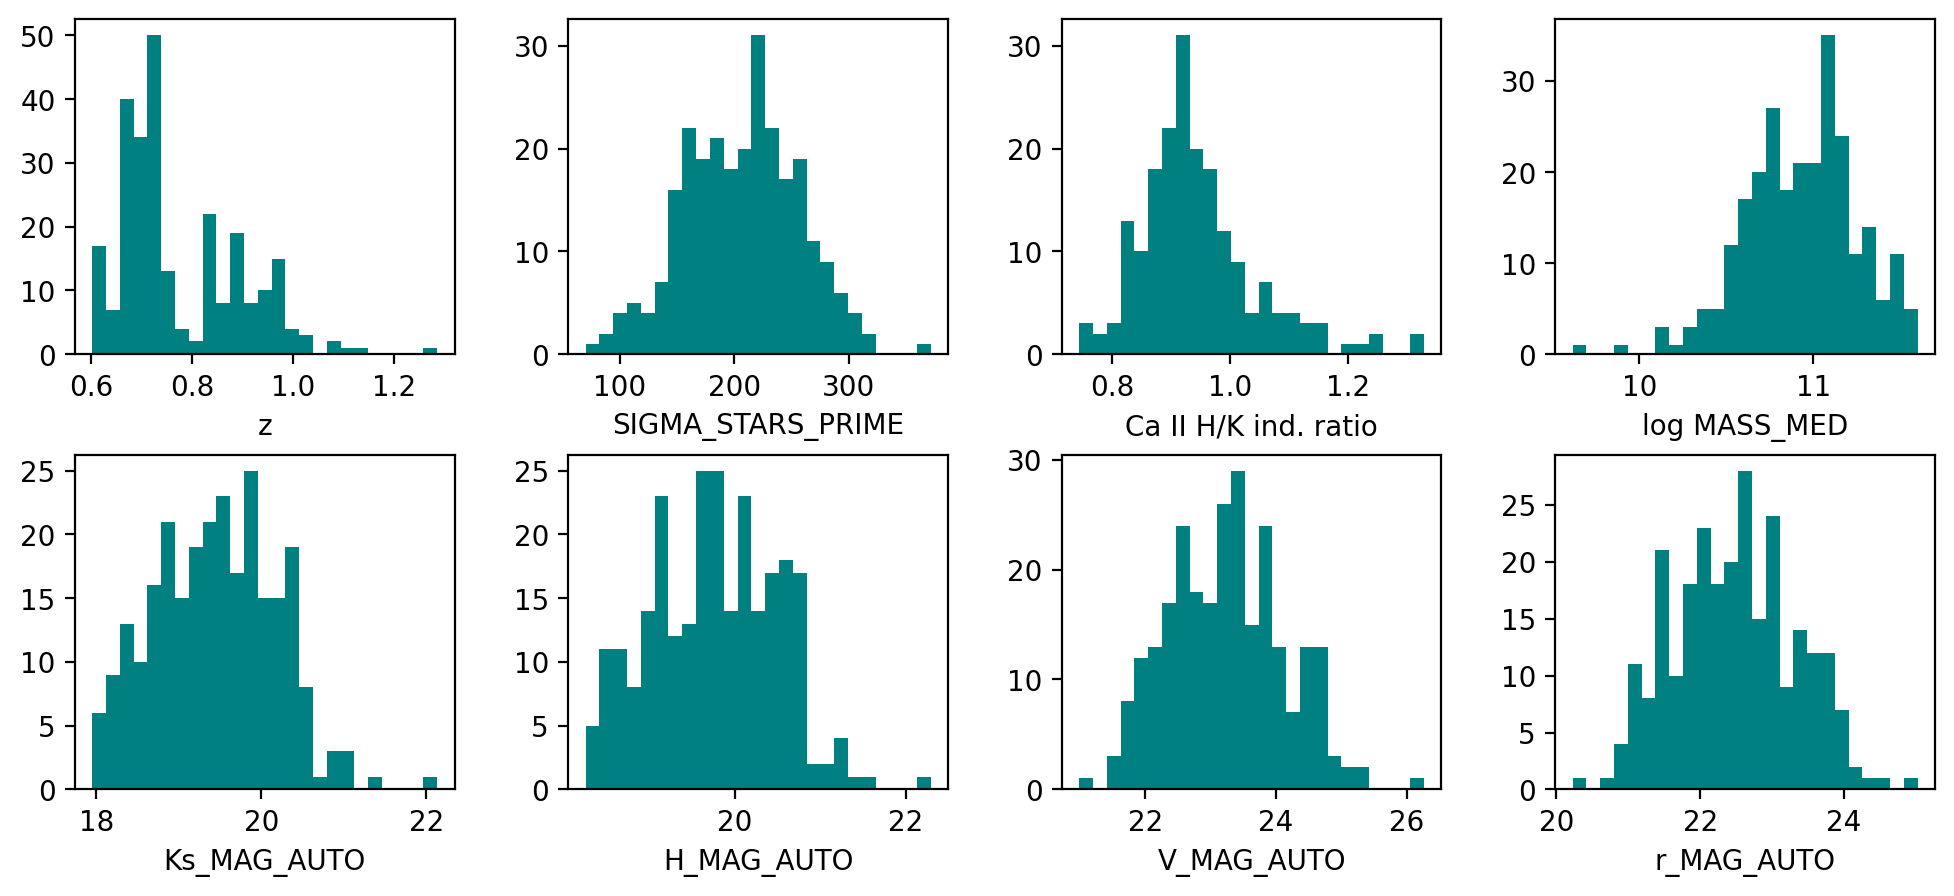

In [ ]:
fig, ax = plt.subplots(2,4, figsize=(12,5), dpi=200)
plt.subplots_adjust(wspace=0.3, hspace=0.3)
ax = ax.flatten()

ax[0].hist(matched["Z"], bins=25, color="teal")
ax[0].set_xlabel("z")

ax[1].hist(matched["SIGMA_STARS_PRIME"], bins=25, color="teal")
ax[1].set_xlabel("SIGMA_STARS_PRIME")


HK = matched["exact_CaII_H"]/matched["exact_CaII_K"]
ax[2].hist(HK, bins=25, color="teal")
ax[2].set_xlabel("Ca II H/K ind. ratio")

ax[3].hist(matched["MASS_MED"], bins=25, color="teal")
ax[3].set_xlabel("log MASS_MED")


todos = ["Ks_MAG_AUTO", "H_MAG_AUTO", "V_MAG_AUTO", "r_MAG_AUTO"]

for i, k in enumerate(todos):
    ax[i+4].hist(matched[k], bins=25, color="teal")
    ax[i+4].set_xlabel(k)


plt.show()

In [ ]:
waves = []
fluxes = []
zs = np.array(matched["Z"])
SN_med = np.zeros_like(zs)
SN_mean = np.zeros_like(zs)

for i in tqdm(range(len(matched))):
    wave, flux, ferr, mask = load_spectrum(matched["OBJECT"][i])
    waves.append(wave)
    fluxes.append(flux)

    SN = flux[mask]/ferr[mask]
    SN_med[i] = np.nanmedian(SN)
    SN_mean[i] = np.nanmean(SN)


100%|██████████| 261/261 [00:53<00:00,  4.86it/s]


In [ ]:
todo = ["1z", "2z", "3z"][2]

# Selection 1z
if todo=="1z":
    selectz = (0.6 <= zs) & (zs <= 0.8)
    select1 = selectz & (SN_med > np.percentile(SN_med, 77.5))
    select1 &= np.isin(matched["OBJECT"], resultsB22["ID"])
    print(np.percentile(SN_med, 77.5))
    selectf = select1


# Selection 2z
if todo=="2z":
    selectz = (0.6 <= zs) & (zs <= 0.8)
    select1 = selectz & (SN_med > 15) & np.isin(matched["OBJECT"], resultsB22["ID"])

    select_high = select1 & (SN_med > 50)
    select_pool = select1 & (SN_med <= 50)

    rng = np.random.default_rng(42)
    h, e = np.histogram(zs[select_pool], bins=20)
    w = 1 / h[np.digitize(zs[select_pool], e[:-1]) - 1]
    n_fill = 44 - select_high.sum()
    idx = rng.choice(np.where(select_pool)[0], n_fill, replace=False, p=w / w.sum())

    selectf = select_high | np.isin(np.arange(len(zs)), idx)

    print(f"High SN: {select_high.sum()}, Weighted: {n_fill}, Total: {selectf.sum()}")

# Selection 3z
if todo=="3z":
    selectz = (0.6 <= zs) & (zs <= 0.9)
    select1 = selectz & (SN_med > 15) & np.isin(matched["OBJECT"], resultsB22["ID"])

    select_high = select1 & (SN_med > 50)
    select_pool = select1 & (SN_med <= 50)

    rng = np.random.default_rng(42)
    h, e = np.histogram(zs[select_pool], bins=20)
    w = 1 / h[np.digitize(zs[select_pool], e[:-1]) - 1]
    n_fill = 44 - select_high.sum()
    idx = rng.choice(np.where(select_pool)[0], n_fill, replace=False, p=w / w.sum())

    selectf = select_high | np.isin(np.arange(len(zs)), idx)

    print(f"High SN: {select_high.sum()}, Weighted: {n_fill}, Total: {selectf.sum()}")


print(f"Selected {np.sum(selectz)} objects ({np.sum(selectz)/len(selectz):.2%})")
print(f" > (selectz) ...of which {np.sum(selectz)} objects ({np.sum(selectz)/len(zs):.2%})")
print(f" > (selectf) ...of which {np.sum(selectf)} objects ({np.sum(selectf)/len(zs):.2%})")


High SN: 10, Weighted: 34, Total: 44
Selected 215 objects (82.38%)
 > (selectz) ...of which 215 objects (82.38%)
 > (selectf) ...of which 44 objects (16.86%)


Median SN: 18.93
Median SN selected: 22.34
Median SN final: 29.25


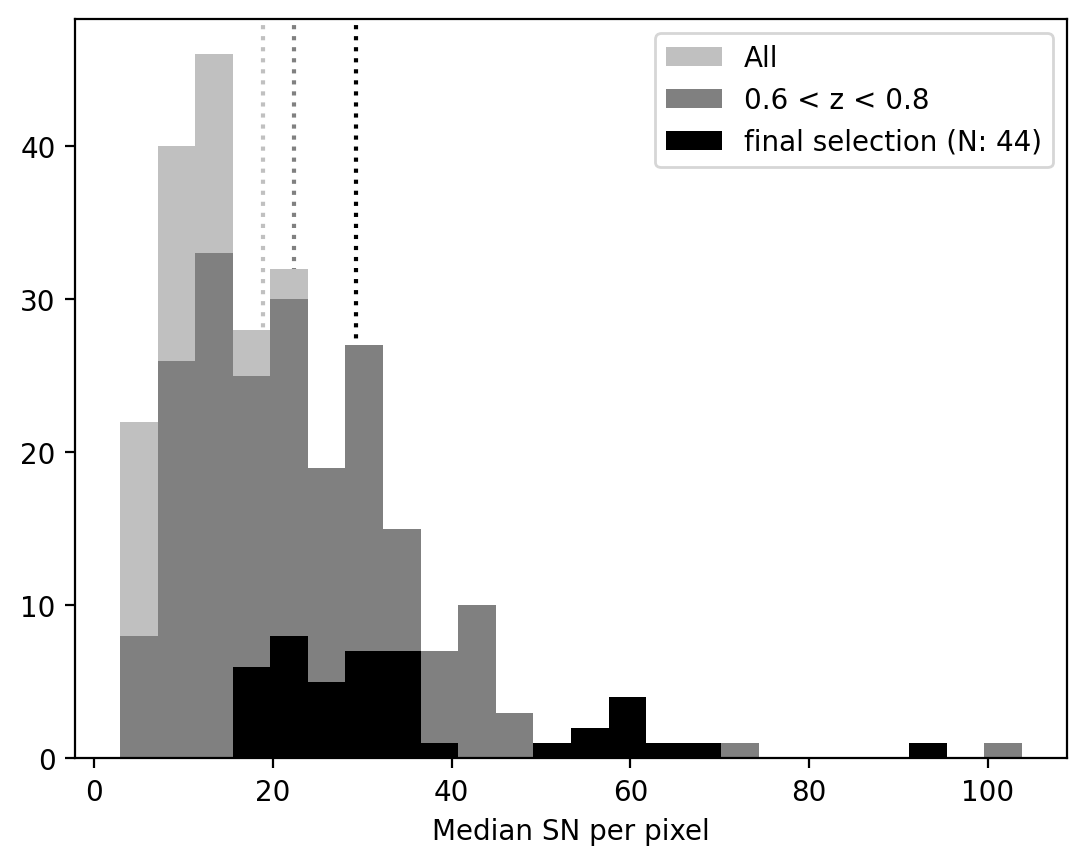

In [ ]:
SNbins = np.linspace(np.min(SN_med), np.max(SN_med), 25)

plt.figure(dpi=200)
plt.hist(SN_med, bins=SNbins, color="silver", label="All")
plt.hist(SN_med[selectz], bins=SNbins, color="grey", label="0.6 < z < 0.8")
plt.hist(SN_med[selectf], bins=SNbins, color="k", label=f"final selection (N: {np.sum(selectf)})")


sample_med = np.median(SN_med)
sample_sel_med = np.median(SN_med[selectz])
sample_self_med = np.median(SN_med[selectf])
plt.axvline(sample_med, color="silver", ls=":", zorder=0)
plt.axvline(sample_sel_med, color="grey", ls=":", zorder=0)
plt.axvline(sample_self_med, color="k", ls=":", zorder=0)

print(f"Median SN: {sample_med:.2f}")
print(f"Median SN selected: {sample_sel_med:.2f}")
print(f"Median SN final: {sample_self_med:.2f}")


plt.xlabel("Median SN per pixel")
plt.legend()
plt.show()


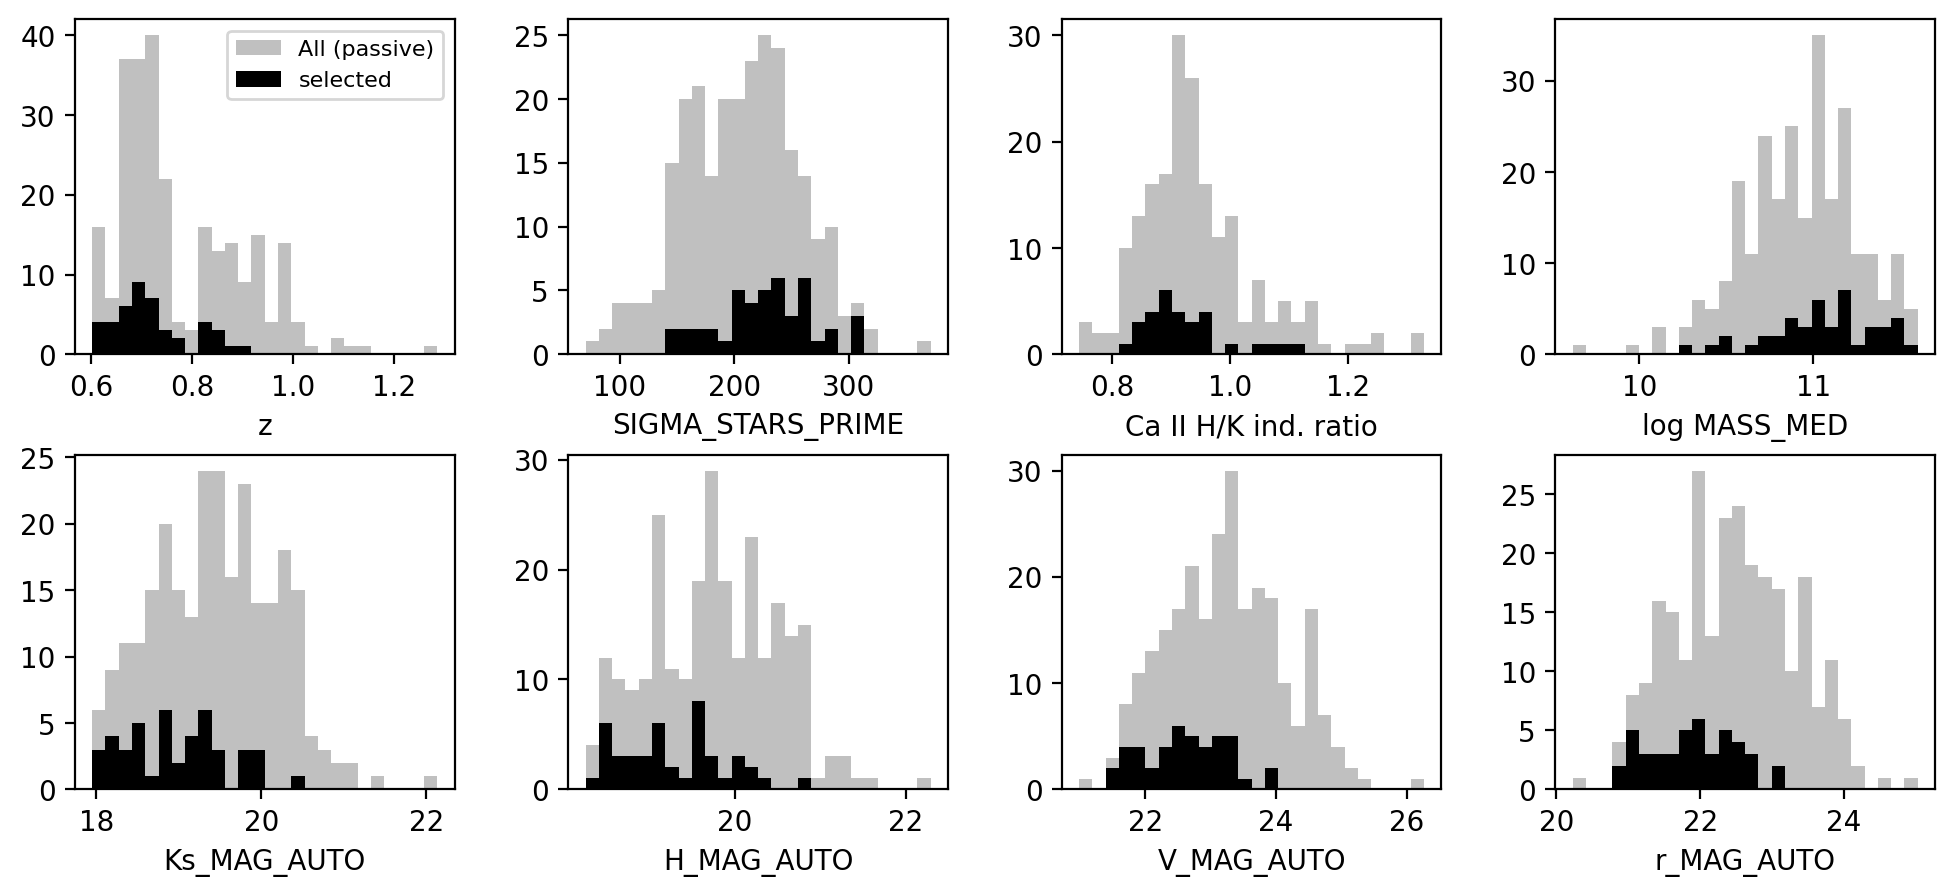

In [ ]:
fig, ax = plt.subplots(2, 4, figsize=(12, 5), dpi=200)
plt.subplots_adjust(wspace=0.3, hspace=0.3)
ax = ax.flatten()

# Handle masked columns
HK_ratio = (matched["exact_CaII_H"].filled(np.nan) /
            matched["exact_CaII_K"].filled(np.nan))

cols = ["Z", "SIGMA_STARS_PRIME", HK_ratio, "MASS_MED",
        "Ks_MAG_AUTO", "H_MAG_AUTO", "V_MAG_AUTO", "r_MAG_AUTO"]
labels = ["z", "SIGMA_STARS_PRIME", "Ca II H/K ind. ratio", "log MASS_MED",
          "Ks_MAG_AUTO", "H_MAG_AUTO", "V_MAG_AUTO", "r_MAG_AUTO"]

for i, (col, label) in enumerate(zip(cols, labels)):
    if isinstance(col, np.ndarray):
        data_full = col
    else:
        data_full = matched[col].filled(np.nan) if hasattr(matched[col], 'filled') else np.array(matched[col])
    data_sub = data_full[selectf]

    bins = np.histogram_bin_edges(data_full[np.isfinite(data_full)], bins=26)

    ax[i].hist(data_full, bins=bins, color="silver", label="All (passive)")
    ax[i].hist(data_sub, bins=bins, color="k", label="selected")
    ax[i].set_xlabel(label)

ax[0].legend(fontsize=8)
plt.show()

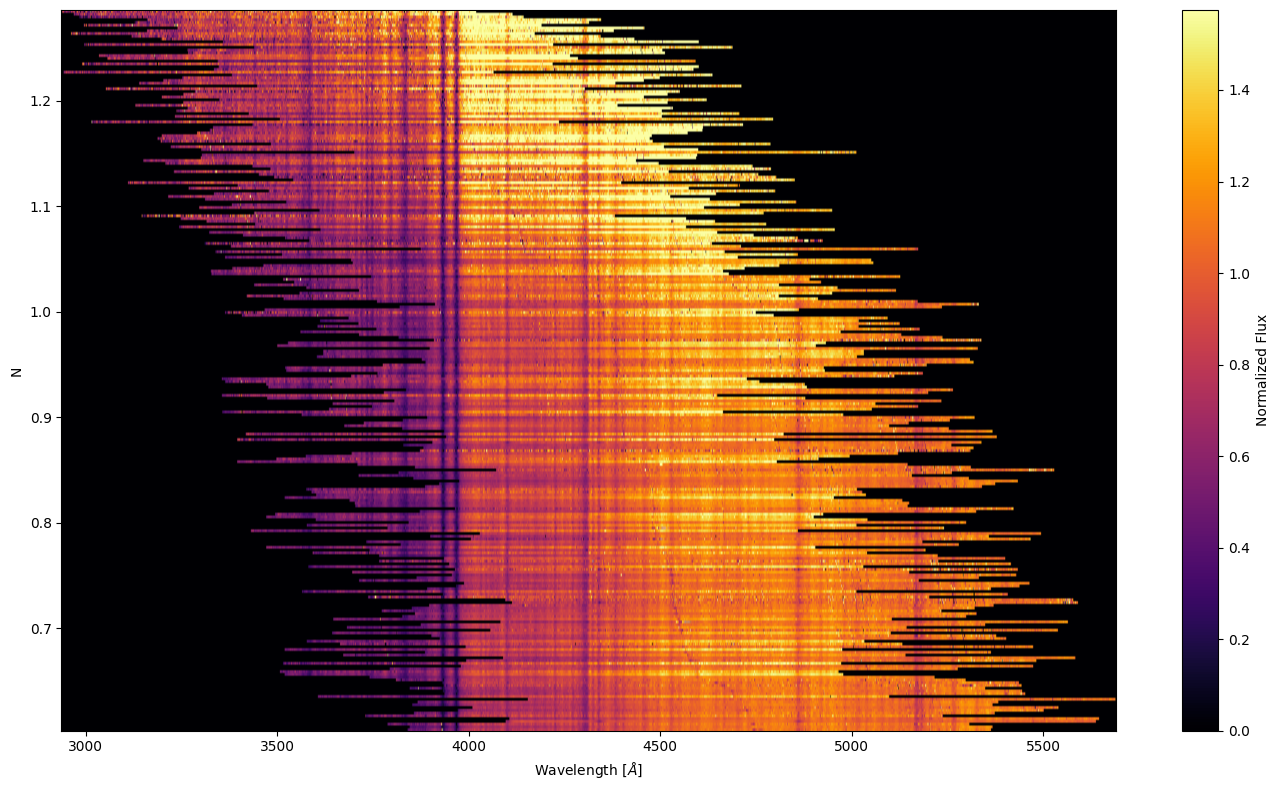

In [ ]:
# Sort by redshift
sort_idx = np.argsort(zs)
zs_sorted = zs[sort_idx]
waves_sorted = [waves[i] for i in sort_idx]
fluxes_sorted = [fluxes[i] for i in sort_idx]

# Full wavelength grid covering all spectra
wave_min = min([w.min() for w in waves_sorted])
wave_max = max([w.max() for w in waves_sorted])
wave_grid = np.linspace(wave_min, wave_max, 2000)

# Build 2D array, zeros where no data
flux_2d = np.zeros((len(zs_sorted), len(wave_grid)))
for i, (w, f) in enumerate(zip(waves_sorted, fluxes_sorted)):
    idx_min = np.searchsorted(wave_grid, w.min())
    idx_max = np.searchsorted(wave_grid, w.max())
    flux_2d[i, idx_min:idx_max] = np.interp(wave_grid[idx_min:idx_max], w, f)

# Normalize each spectrum (mask zeros)
flux_2d_masked = np.where(flux_2d > 0, flux_2d, np.nan)
medians = np.nanmedian(flux_2d_masked, axis=1, keepdims=True)
flux_2d_norm = flux_2d / medians
flux_2d_norm[flux_2d == 0] = 0  # restore zeros

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(flux_2d_norm, aspect="auto", origin="lower",
               extent=[wave_grid[0], wave_grid[-1], zs_sorted[0], zs_sorted[-1]],
               cmap="inferno", vmin=0, vmax=np.nanpercentile(flux_2d_norm[flux_2d_norm>0], 95))


ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel("N")
plt.colorbar(im, ax=ax, label="Normalized Flux")
plt.tight_layout()
plt.show()

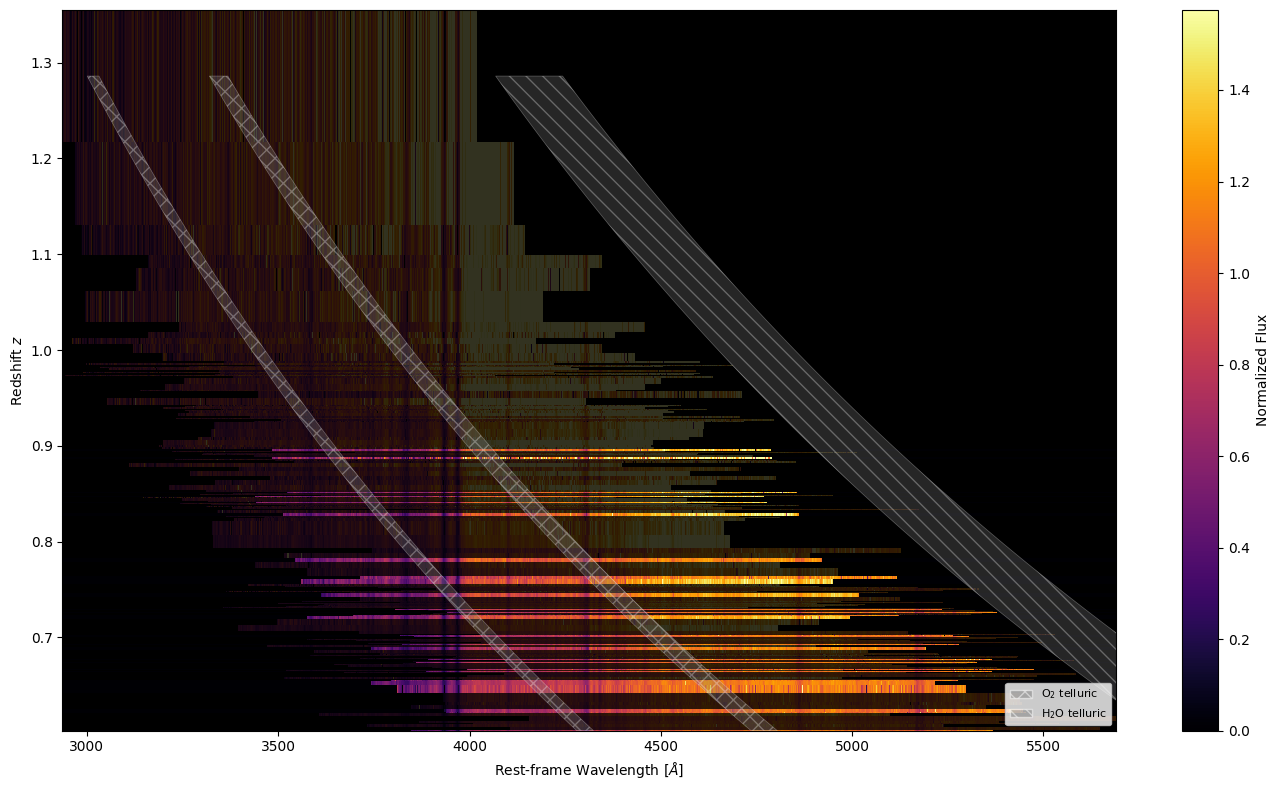

In [ ]:
# Sort by redshift
sort_idx = np.argsort(zs)
zs_sorted = zs[sort_idx]
waves_sorted = [waves[i] for i in sort_idx]
fluxes_sorted = [fluxes[i] for i in sort_idx]

# =============================================================
# MASK (define on original data, then sort)
# =============================================================
mask = np.ones(len(zs), dtype=bool)  # Default: show all
mask = selectf  # User-provided mask
mask_sorted = mask[sort_idx]

alpha_highlight = 1.0
alpha_faded = 0.2

# =============================================================
# TOGGLE: Telluric bands overlay
# =============================================================
show_telluric_bands = True

# =============================================================
# Telluric absorption bands (observed frame, Angstrom)
# Uncomment/comment lines to select which bands to display
# =============================================================
telluric_bands = {
    r"O$_2$ B":      (6860, 6930, "O2"),
    r"O$_2$ A":      (7590, 7700, "O2"),
    r"H$_2$O 0.94":  (9300, 9700, "H2O"),
    # r"H$_2$O 1.13":  (11100, 11600, "H2O"),
    # r"O$_2$ 1.27":   (12600, 12900, "O2"),
    # r"H$_2$O 1.4":   (13500, 14500, "H2O"),
    # r"CO$_2$ 1.6":   (15700, 16100, "CO2"),
    # r"CH$_4$ 1.66":  (16400, 16700, "CH4"),
    # r"H$_2$O 1.9":   (17800, 20000, "H2O"),
    # r"CO$_2$ 2.0":   (20100, 20500, "CO2"),
    # r"CH$_4$ 2.2":   (22000, 22500, "CH4"),
    # r"H$_2$O 2.5+":  (24500, 28000, "H2O"),
}

# Hatches and color for different molecules
hatches = {"O2": "xx", "H2O": "\\\\", "CO2": "//", "CH4": ".."}
telluric_color = "gray"

# =============================================================
# Build wavelength grid
# =============================================================
wave_min = min([w.min() for w in waves_sorted])
wave_max = max([w.max() for w in waves_sorted])
wave_grid = np.linspace(wave_min, wave_max, 2000)

# Build 2D array, zeros where no data
flux_2d = np.zeros((len(zs_sorted), len(wave_grid)))
for i, (w, f) in enumerate(zip(waves_sorted, fluxes_sorted)):
    idx_min = np.searchsorted(wave_grid, w.min())
    idx_max = np.searchsorted(wave_grid, w.max())
    flux_2d[i, idx_min:idx_max] = np.interp(wave_grid[idx_min:idx_max], w, f)

# Normalize each spectrum (mask zeros)
flux_2d_masked = np.where(flux_2d > 0, flux_2d, np.nan)
medians = np.nanmedian(flux_2d_masked, axis=1, keepdims=True)
flux_2d_norm = flux_2d / medians
flux_2d_norm[flux_2d == 0] = 0  # restore zeros

# Create RGBA for masking
vmin = 0
vmax = np.nanpercentile(flux_2d_norm[flux_2d_norm > 0], 95)
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.inferno
rgba = cmap(norm(flux_2d_norm))

# Apply alpha based on mask
alpha_array = np.where(mask_sorted[:, np.newaxis], alpha_highlight, alpha_faded)
rgba[..., 3] = alpha_array

# Create z edges for pcolormesh (non-uniform y-axis)
z_edges = np.zeros(len(zs_sorted) + 1)
z_edges[1:-1] = 0.5 * (zs_sorted[:-1] + zs_sorted[1:])
z_edges[0] = zs_sorted[0] - 0.5 * (zs_sorted[1] - zs_sorted[0])
z_edges[-1] = zs_sorted[-1] + 0.5 * (zs_sorted[-1] - zs_sorted[-2])

# =============================================================
# PLOT
# =============================================================
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_facecolor("black")

wave_edges = np.linspace(wave_min, wave_max, len(wave_grid) + 1)
im = ax.pcolormesh(wave_edges, z_edges, rgba, shading='flat')

# --- Telluric bands (rest-frame projection) ---
if show_telluric_bands:
    z_arr = np.linspace(zs_sorted[0], zs_sorted[-1], 200)
    molecules_plotted = set()

    for name, (lam_min, lam_max, mol) in telluric_bands.items():
        # Convert observed-frame telluric to rest-frame at each redshift
        rest_min = lam_min / (1 + z_arr)
        rest_max = lam_max / (1 + z_arr)
        ax.fill_betweenx(z_arr, rest_min, rest_max, color=telluric_color, alpha=0.3,
                         hatch=hatches[mol], edgecolor="white", linewidth=0.5)
        molecules_plotted.add(mol)

    # Build legend for telluric molecules actually plotted
    legend_elements = []
    mol_labels = {"O2": r"O$_2$ telluric", "H2O": r"H$_2$O telluric",
                  "CO2": r"CO$_2$ telluric", "CH4": r"CH$_4$ telluric"}
    for mol in ["O2", "H2O", "CO2", "CH4"]:
        if mol in molecules_plotted:
            legend_elements.append(
                Patch(facecolor=telluric_color, alpha=0.5, hatch=hatches[mol],
                      edgecolor="white", label=mol_labels[mol])
            )
    ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

ax.set_xlabel(r"Rest-frame Wavelength [$\AA$]")
ax.set_ylabel("Redshift $z$")
ax.set_xlim(wave_grid[0], wave_grid[-1])
ax.set_ylim(z_edges[0], z_edges[-1])

# Colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Normalized Flux")

plt.tight_layout()
plt.show()

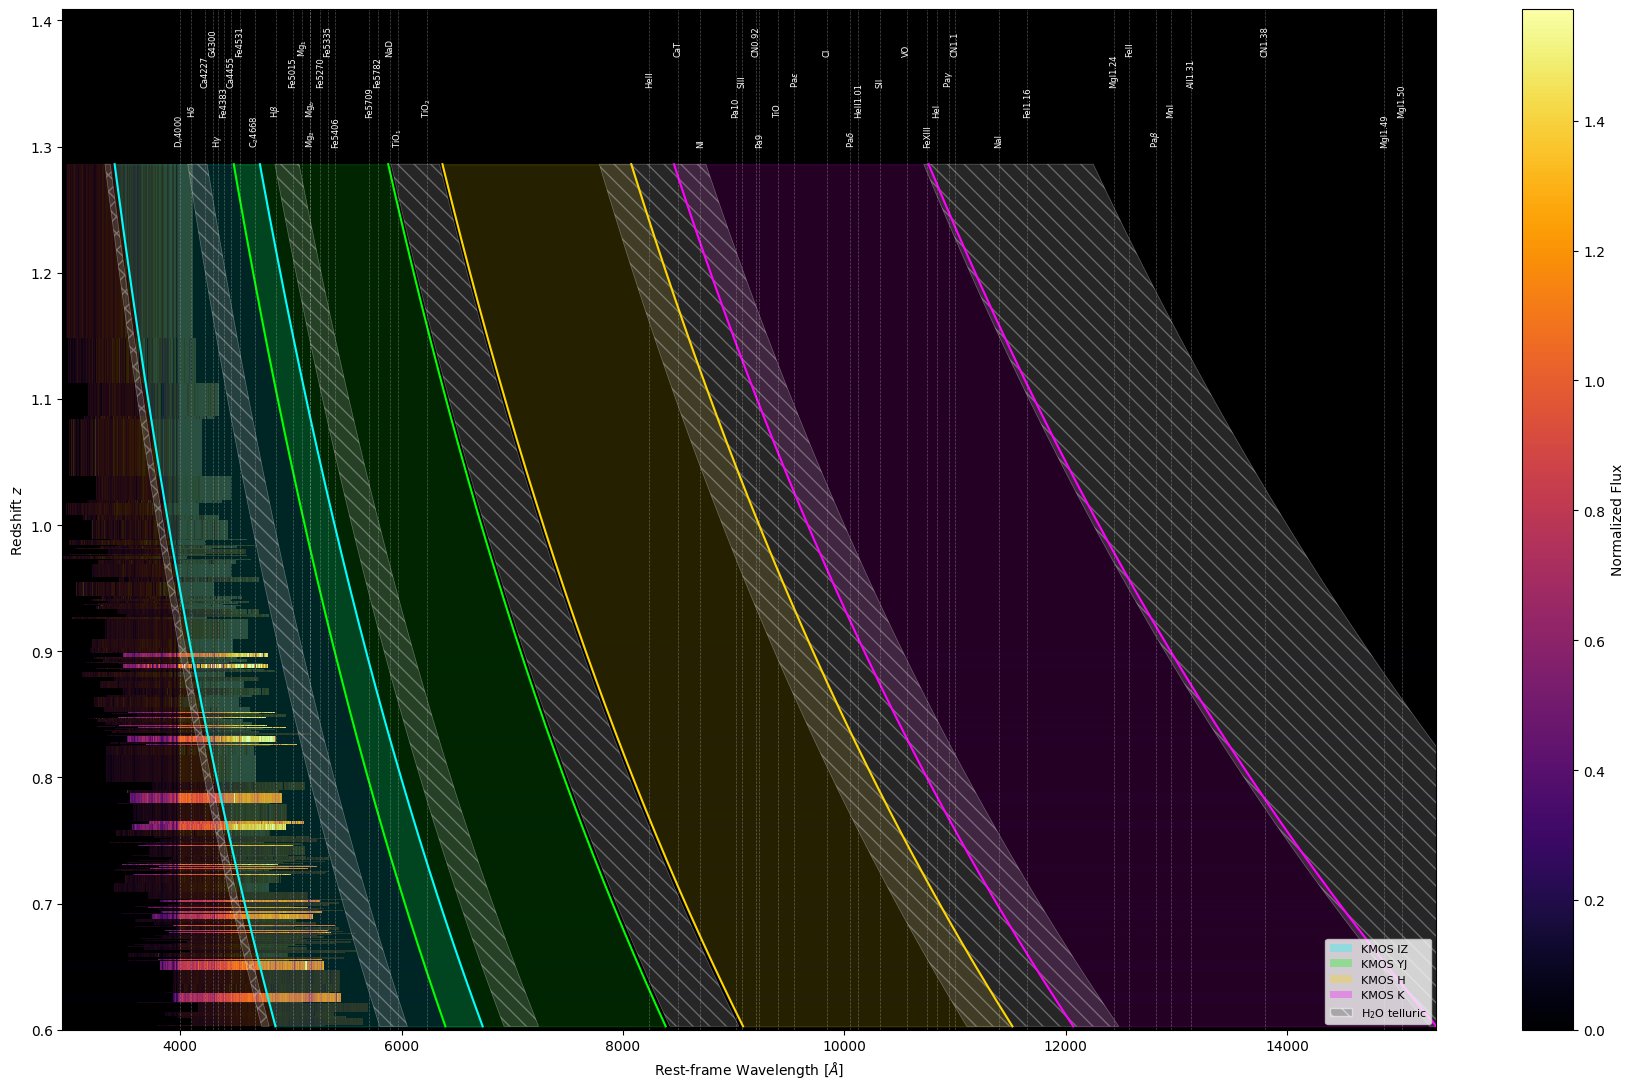

In [ ]:
# MASK (Select spectra to highlight)
mask = np.ones(len(zs), dtype=bool)  # or use select1
mask = selectf
# print(f"masked: {np.sum(mask)}")

# Sort by redshift
sort_idx = np.argsort(zs)
zs_sorted = zs[sort_idx]
waves_sorted = [waves[i] for i in sort_idx]
fluxes_sorted = [fluxes[i] for i in sort_idx]
mask_sorted = mask[sort_idx]


# mask_sorted = mask[sort_idx]


# Visualization parameters (modifiable)
alpha_highlight = 1.0   # Alpha for selected spectra
alpha_faded = 0.2       # Alpha for non-selected spectra

# KMOS spectral bands (observed frame, Angstrom)
kmos_bands = {
    "IZ": (7790, 10790),
    "YJ": (10250, 13440),
    "H":  (14560, 18460),
    "K":  (19340, 24600),
}

# All absorption/emission features (rest-frame wavelength in Angstrom)
features = {
    # Optical Lick indices
    r"D$_n$4000": 4000,
    r"H$\delta$": 4102,
    "Ca4227": 4228,
    "G4300": 4299,
    r"H$\gamma$": 4341,
    "Fe4383": 4395,
    "Ca4455": 4463,
    "Fe4531": 4537,
    r"C$_2$4668": 4677,
    r"H$\beta$": 4862,
    "Fe5015": 5016,
    r"Mg$_1$": 5102,
    r"Mg$_2$": 5175,
    r"Mg$_b$": 5176,
    "Fe5270": 5266,
    "Fe5335": 5332,
    "Fe5406": 5401,
    "Fe5709": 5709,
    "Fe5782": 5787,
    "NaD": 5893,
    r"TiO$_1$": 5965,
    r"TiO$_2$": 6231,
    # NIR features
    "HeII": 8239,
    "CaT": 8500,
    "NI": 8700,
    "Pa10": 9017,
    "SIII": 9071,
    "CN0.92": 9200,
    "Pa9": 9232,
    "TiO": 9400,
    r"Pa$\epsilon$": 9549,
    "CI": 9840,
    r"Pa$\delta$": 10052,
    "HeII1.01": 10125,
    "SII": 10320,
    "VO": 10563,
    "FeXIII": 10750,
    "HeI": 10833,
    r"Pa$\gamma$": 10941,
    "CN1.1": 11000,
    "NaI": 11393,
    "FeI1.16": 11653,
    "MgI1.24": 12433,
    "FeII": 12573,
    r"Pa$\beta$": 12815,
    "MnI": 12948,
    "AlI1.31": 13136,
    "CN1.38": 13800,
    "MgI1.49": 14879,
    "MgI1.50": 15037,
    "OH1.53": 15350,
    "CO1.56": 15584,
    "CO1.58": 15774,
    "SiI1.59": 15894,
    "CO1.60": 15984,
    "Hbump": 16000,
    "OH1.61": 16064,
    "CO1.62": 16194,
    "CO1.64": 16404,
    "CO1.65": 16525,
    "CO1.66": 16615,
    "SiI1.67": 16695,
    "AlI1.67": 16750,
    "OH1.69": 16895,
    "MgI1.71": 17105,
    "OH1.72": 17235,
    "SiI1.73": 17335,
    "CN1.77": 17700,
}

# Major telluric absorption bands (observed frame, Angstrom)
telluric_bands = {
    # r"O$_2$ B":      (6860, 6930, "O2"),
    r"O$_2$ A":      (7590, 7700, "O2"),
    r"H$_2$O 0.94":  (9300, 9700, "H2O"),
    r"H$_2$O 1.13":  (11100, 11600, "H2O"),
    # r"O$_2$ 1.27":   (12600, 12900, "O2"),
    r"H$_2$O 1.4":   (13500, 14500, "H2O"),
    # r"CO$_2$ 1.6":   (15700, 16100, "CO2"),
    # r"CH$_4$ 1.66":  (16400, 16700, "CH4"),
    r"H$_2$O 1.9":   (17800, 20000, "H2O"),
    # r"CO$_2$ 2.0":   (20100, 20500, "CO2"),
    # r"CH$_4$ 2.2":   (22000, 22500, "CH4"),
    r"H$_2$O 2.5+":  (24500, 28000, "H2O"),
}

# Hatches for different molecules (same color)
hatches = {"O2": "xx", "H2O": "\\\\", "CO2": "//", "CH4": ".."}

# Full wavelength grid
kmos_obs_min = 7790
kmos_obs_max = 24600
wave_min_data = min([w.min() for w in waves_sorted])
wave_max_data = max([w.max() for w in waves_sorted])
wave_min = min(wave_min_data, kmos_obs_min / (1 + zs_sorted.max()))
wave_max = max(wave_max_data, kmos_obs_max / (1 + zs_sorted.min()))
wave_grid = np.linspace(wave_min, wave_max, 3000)

# Build 2D array
flux_2d = np.zeros((len(zs_sorted), len(wave_grid)))
for i, (w, f) in enumerate(zip(waves_sorted, fluxes_sorted)):
    idx_min = np.searchsorted(wave_grid, w.min())
    idx_max = np.searchsorted(wave_grid, w.max())
    flux_2d[i, idx_min:idx_max] = np.interp(wave_grid[idx_min:idx_max], w, f)

# Normalize
flux_2d_masked = np.where(flux_2d > 0, flux_2d, np.nan)
medians = np.nanmedian(flux_2d_masked, axis=1, keepdims=True)
flux_2d_norm = flux_2d / medians
flux_2d_norm[flux_2d == 0] = 0

# Apply alpha mask: create RGBA array for selective transparency
vmin = 0
vmax = np.nanpercentile(flux_2d_norm[flux_2d_norm > 0], 95)
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.inferno
rgba = cmap(norm(flux_2d_norm))

# Apply alpha based on mask
alpha_array = np.where(mask_sorted[:, np.newaxis], alpha_highlight, alpha_faded)
rgba[..., 3] = alpha_array * rgba[..., 3]  # Modulate existing alpha

# Plot
fig, ax = plt.subplots(figsize=(18, 11))
ax.set_facecolor("black")
im = ax.pcolormesh(wave_grid, zs_sorted, rgba[:-1, :-1], shading='auto')

# KMOS bands
z_arr = np.linspace(zs_sorted[0], zs_sorted[-1], 200)
colors_kmos = {"IZ": "cyan", "YJ": "lime", "H": "gold", "K": "magenta"}

for band, (lam_min, lam_max) in kmos_bands.items():
    rest_min = lam_min / (1 + z_arr)
    rest_max = lam_max / (1 + z_arr)
    ax.plot(rest_min, z_arr, color=colors_kmos[band], ls="-", lw=1.5)
    ax.plot(rest_max, z_arr, color=colors_kmos[band], ls="-", lw=1.5)
    ax.fill_betweenx(z_arr, rest_min, rest_max, color=colors_kmos[band], alpha=0.15)

# Telluric bands (same color, different hatches)
telluric_color = "gray"
for name, (lam_min, lam_max, mol) in telluric_bands.items():
    rest_min = lam_min / (1 + z_arr)
    rest_max = lam_max / (1 + z_arr)
    ax.fill_betweenx(z_arr, rest_min, rest_max, color=telluric_color, alpha=0.3,
                     hatch=hatches[mol], edgecolor="white", linewidth=0.5)

# Absorption features (vertical lines at top)
y_top = zs_sorted[-1]
y_range = zs_sorted[-1] - zs_sorted[0]

for i, (name, lam) in enumerate(features.items()):
    if wave_min < lam < wave_max:
        ax.axvline(lam, color="silver", ls="--", lw=0.5, alpha=0.4, ymin=0, ymax=1.0)
        offset = 0.02 + 0.035 * (i % 4)
        ax.text(lam, y_top + offset * y_range, name, color="white", fontsize=6,
                ha="center", va="bottom", rotation=90)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors_kmos["IZ"], alpha=0.3, label="KMOS IZ"),
    Patch(facecolor=colors_kmos["YJ"], alpha=0.3, label="KMOS YJ"),
    Patch(facecolor=colors_kmos["H"], alpha=0.3, label="KMOS H"),
    Patch(facecolor=colors_kmos["K"], alpha=0.3, label="KMOS K"),
    # Patch(facecolor=telluric_color, alpha=0.5, hatch="xx", edgecolor="white", label=r"O$_2$ telluric"),
    Patch(facecolor=telluric_color, alpha=0.5, hatch="\\\\", edgecolor="white", label=r"H$_2$O telluric"),
    # Patch(facecolor=telluric_color, alpha=0.5, hatch="//", edgecolor="white", label=r"CO$_2$ telluric"),
    # Patch(facecolor=telluric_color, alpha=0.5, hatch="..", edgecolor="white", label=r"CH$_4$ telluric"),
]

ax.legend(handles=legend_elements, loc="lower right", fontsize=8)
ax.set_xlabel(r"Rest-frame Wavelength [$\AA$]")
ax.set_ylabel("Redshift $z$")
ax.set_ylim(0.6, zs_sorted[-1] + 0.18 * y_range)
ax.set_xlim(wave_min, wave_max)

# Colorbar (using ScalarMappable since we used RGBA directly)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Normalized Flux")

plt.tight_layout()
# plt.savefig("rest_coverage_indices_v2.jpg", dpi=300)
plt.show()

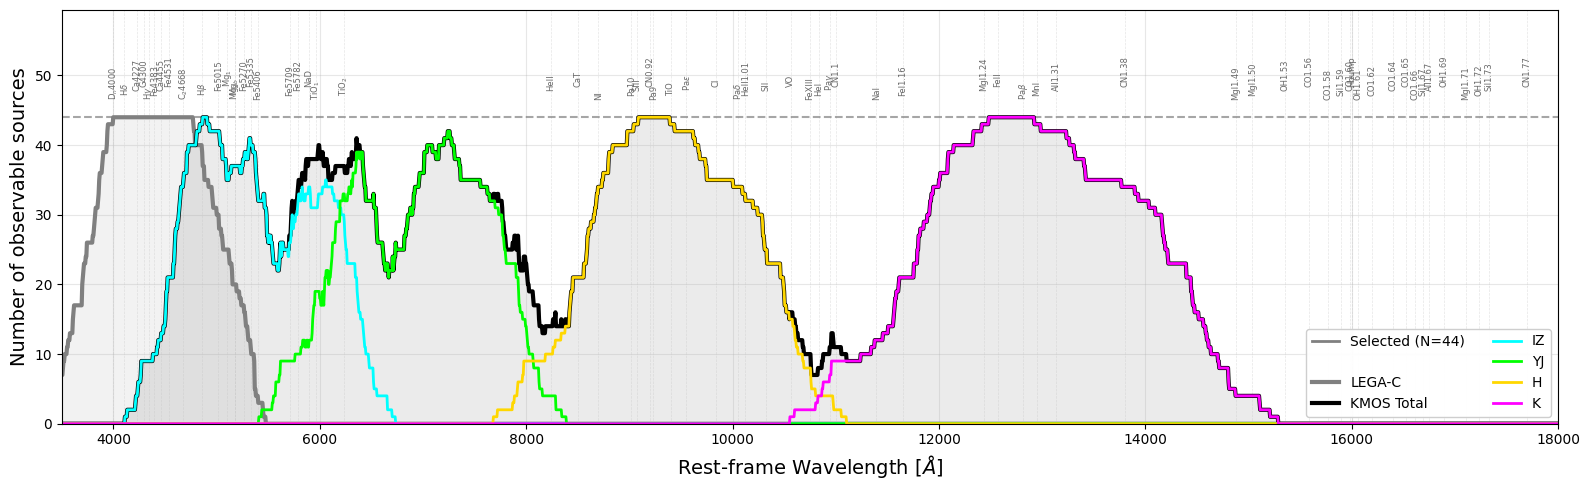

In [ ]:
# ============================================================
# TOGGLE FLAGS
# ============================================================
show_full_sample = False  # Plot full catalog distributions (dotted lines)

# ============================================================
# Compute N(sources) observable at each rest-frame wavelength
# ============================================================
wave_rest_grid = np.linspace(3000, 20000, 3000)
n_sources_full = len(zs)
n_sources_mask = mask.sum()

bands = ["legac", "total", "IZ", "YJ", "H", "K"]
n_full = {b: np.zeros(len(wave_rest_grid)) for b in bands}
n_mask = {b: np.zeros(len(wave_rest_grid)) for b in bands}

def in_telluric(wave_obs):
    tel = np.zeros_like(wave_obs, dtype=bool)
    for lam_min, lam_max, _ in telluric_bands.values():
        tel |= (wave_obs >= lam_min) & (wave_obs <= lam_max)
    return tel

for i in range(n_sources_full):
    z_i, wave_data, is_sel = zs[i], waves[i], mask[i]
    wave_obs = wave_rest_grid * (1 + z_i)
    tel = in_telluric(wave_obs)

    coverage = {
        "legac": (wave_rest_grid >= wave_data.min()) & (wave_rest_grid <= wave_data.max()),
        "IZ": (wave_obs >= 7790) & (wave_obs <= 10790) & ~tel,
        "YJ": (wave_obs >= 10250) & (wave_obs <= 13440) & ~tel,
        "H": (wave_obs >= 14560) & (wave_obs <= 18460) & ~tel,
        "K": (wave_obs >= 19340) & (wave_obs <= 24600) & ~tel,
    }
    coverage["total"] = coverage["IZ"] | coverage["YJ"] | coverage["H"] | coverage["K"]

    for b in bands:
        n_full[b] += coverage[b].astype(float)
        if is_sel:
            n_mask[b] += coverage[b].astype(float)

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(16, 5))

colors = {"legac": "gray", "total": "black", "IZ": "cyan", "YJ": "lime", "H": "gold", "K": "magenta"}
lw = {"legac": 3, "total": 3, "IZ": 2, "YJ": 2, "H": 2, "K": 2}
xlim = (3500, 18000)

# Adaptive y limits
y_data_max = n_sources_full if show_full_sample else n_sources_mask
ymax = y_data_max * 1.35

# Reference lines & full sample
if show_full_sample:
    ax.axhline(n_sources_full, color='gray', ls=':', lw=1.5, alpha=0.5)
    for b in bands:
        ax.plot(wave_rest_grid, n_full[b], ':', color=colors[b], lw=lw[b], alpha=0.4)
ax.axhline(n_sources_mask, color='gray', ls='--', lw=1.5, alpha=0.7)

# Selected sample (solid)
for b in bands:
    ax.plot(wave_rest_grid, n_mask[b], '-', color=colors[b], lw=lw[b], alpha=1.0)

ax.fill_between(wave_rest_grid, 0, n_mask["legac"], alpha=0.1, color="gray")
ax.fill_between(wave_rest_grid, 0, n_mask["total"], alpha=0.08, color="black")

# Spectral features
y_top, y_range = y_data_max * 1.05, y_data_max * 0.25
for i, (name, lam) in enumerate(features.items()):
    if xlim[0] < lam < xlim[1]:
        ax.axvline(lam, color='silver', ls='--', lw=0.5, alpha=0.4, zorder=1)
        ax.text(lam, y_top + (0.02 + 0.06 * (i % 4)) * y_range, name, rotation=90,
                va='bottom', ha='center', fontsize=6, color='dimgray')

# Formatting
ax.set_xlabel(r'Rest-frame Wavelength [$\AA$]', fontsize=14)
ax.set_ylabel('Number of observable sources', fontsize=14)
ax.set_xlim(xlim)
ax.set_ylim(0, ymax)

# Legend
legend_elements = []
if show_full_sample:
    legend_elements.append(Line2D([0], [0], color='gray', ls=':', lw=2, alpha=0.4, label=f'Full (N={n_sources_full})'))
legend_elements += [
    Line2D([0], [0], color='gray', ls='-', lw=2, label=f'Selected (N={n_sources_mask})'),
    Line2D([0], [0], color='white', lw=0, label=''),
] + [Line2D([0], [0], color=colors[b], ls='-', lw=lw[b],
            label=b.upper() if b not in ["legac","total"] else ("LEGA-C" if b=="legac" else "KMOS Total"))
     for b in bands]

ax.legend(handles=legend_elements, loc='lower right', fontsize=10, framealpha=0.95, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('n_sources_vs_wavelength.jpg', dpi=200, bbox_inches='tight')
plt.show()

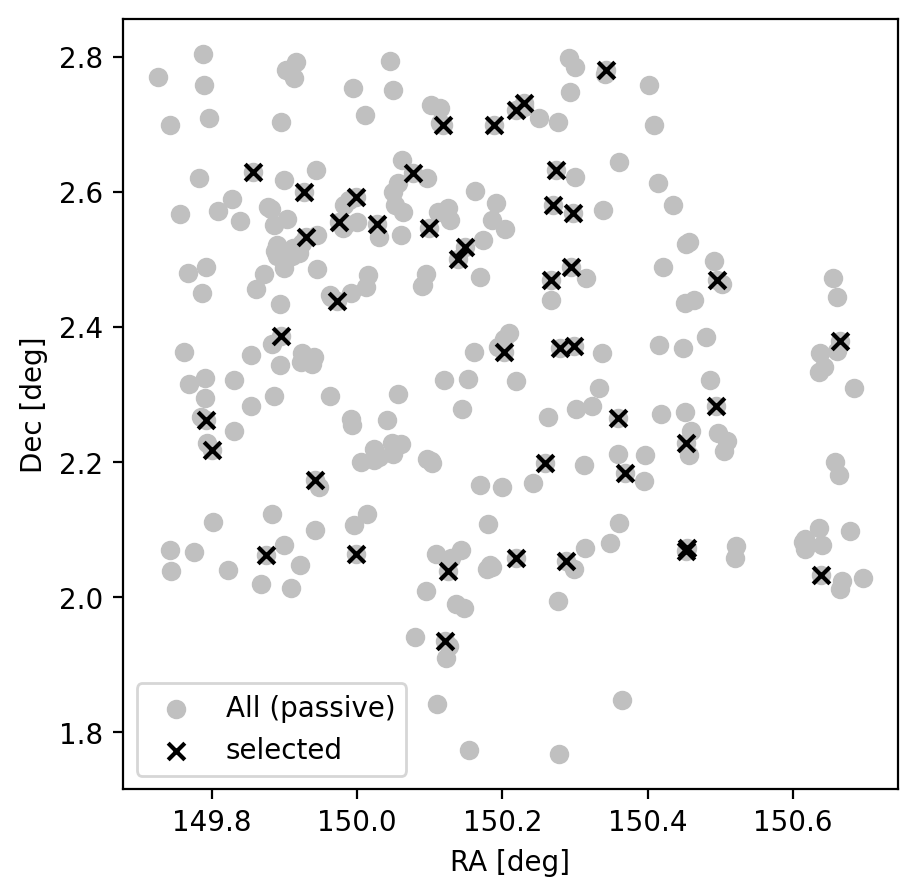

In [ ]:
plt.figure(figsize=(5,5), dpi=200)
plt.scatter(matched["RAJ2000"], matched["DECJ2000"], color="silver", label="All (passive)")

plt.scatter(matched["RAJ2000"][selectf], matched["DECJ2000"][selectf], color="k", marker="x", label="selected")

plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.legend()
plt.show()

In [38]:
print(f"Selection '{todo}'")

# OBJECT COLUMN CORRESPONDS TO SIMBAD [MMS2013] ENTRY
matched[selectf].pprint_all()

Selection '3z'
OBJECT   SPECT_ID       RAJ2000            DECJ2000                Filename          FLAG_PRIMARY   Z    SIGMA_STARS_PRIME SIGMA_STARS_PRIME_ERR SIGMA_GAS_PRIME SIGMA_GAS_PRIME_ERR LICK_HD_A LICK_HD_A_ERR LICK_HD_F LICK_HD_F_ERR LICK_HG_A LICK_HG_A_ERR LICK_HG_F LICK_HG_F_ERR LICK_HB  LICK_HB_ERR LICK_CN1 LICK_CN1_ERR LICK_CN2 LICK_CN2_ERR LICK_CA4227 LICK_CA4227_ERR LICK_G4300 LICK_G4300_ERR LICK_FE4383 LICK_FE4383_ERR LICK_CA4455 LICK_CA4455_ERR LICK_FE4531 LICK_FE4531_ERR LICK_C4668 LICK_C4668_ERR LICK_FE5015 LICK_FE5015_ERR LICK_MG1 LICK_MG1_ERR LICK_MG2 LICK_MG2_ERR LICK_MGB LICK_MGB_ERR LICK_FE5270 LICK_FE5270_ERR LICK_FE5335 LICK_FE5335_ERR LICK_FE5406 LICK_FE5406_ERR LICK_D4000_N LICK_D4000_N_ERR    OII_3727_FLUX        OII_3727_ERR    OII_3727_EW OII_3727_EW_ERR   NEIII_3869_FLUX      NEIII_3869_ERR   NEIII_3869_EW NEIII_3869_EW_ERR    HEI_3890_FLUX        HEI_3890_ERR    HEI_3890_EW HEI_3890_EW_ERR       Hd_FLUX              Hd_ERR        Hd_EW   Hd_EW_ERR     

In [34]:
list(matched.columns) #.columns#["ID2015"]

['OBJECT',
 'SPECT_ID',
 'RAJ2000',
 'DECJ2000',
 'Filename',
 'FLAG_PRIMARY',
 'Z',
 'SIGMA_STARS_PRIME',
 'SIGMA_STARS_PRIME_ERR',
 'SIGMA_GAS_PRIME',
 'SIGMA_GAS_PRIME_ERR',
 'LICK_HD_A',
 'LICK_HD_A_ERR',
 'LICK_HD_F',
 'LICK_HD_F_ERR',
 'LICK_HG_A',
 'LICK_HG_A_ERR',
 'LICK_HG_F',
 'LICK_HG_F_ERR',
 'LICK_HB',
 'LICK_HB_ERR',
 'LICK_CN1',
 'LICK_CN1_ERR',
 'LICK_CN2',
 'LICK_CN2_ERR',
 'LICK_CA4227',
 'LICK_CA4227_ERR',
 'LICK_G4300',
 'LICK_G4300_ERR',
 'LICK_FE4383',
 'LICK_FE4383_ERR',
 'LICK_CA4455',
 'LICK_CA4455_ERR',
 'LICK_FE4531',
 'LICK_FE4531_ERR',
 'LICK_C4668',
 'LICK_C4668_ERR',
 'LICK_FE5015',
 'LICK_FE5015_ERR',
 'LICK_MG1',
 'LICK_MG1_ERR',
 'LICK_MG2',
 'LICK_MG2_ERR',
 'LICK_MGB',
 'LICK_MGB_ERR',
 'LICK_FE5270',
 'LICK_FE5270_ERR',
 'LICK_FE5335',
 'LICK_FE5335_ERR',
 'LICK_FE5406',
 'LICK_FE5406_ERR',
 'LICK_D4000_N',
 'LICK_D4000_N_ERR',
 'OII_3727_FLUX',
 'OII_3727_ERR',
 'OII_3727_EW',
 'OII_3727_EW_ERR',
 'NEIII_3869_FLUX',
 'NEIII_3869_ERR',
 'NEIII_3869_